In [50]:
import pandas as pd
import polars as pl
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
pd.set_option('display.max_columns', None)
path = "/home/diego/BigData/TFM_0/archive/data/bronze/"

In [3]:
!ls $path

complete_fraud_data.parquet


In [13]:
# !pip install fastparquet

In [ ]:
### No usar read_parquet con pyarrow porque da error con las columnas almacenadas como categorias
### No usar read_parquet con fastparquet colapsa la memoria
### Tercera solucion funciona pero consume bastante memoria
### Cargar con polars y limitar filas mejor opcion

# df = pd.read_parquet(
#     f"{path}complete_fraud_data.parquet", 
#     engine='fastparquet'
# )

# df.head(10)

In [3]:
# import pyarrow as pa
# import pyarrow.parquet as pq


# esquema_original = pq.read_schema(f"{path}complete_fraud_data.parquet")
# nuevos_campos = []

# for campo in esquema_original:
#     if pa.types.is_dictionary(campo.type):
#         if pa.types.is_uint32(campo.type.index_type) or pa.types.is_uint16(campo.type.index_type):
#             nuevo_tipo = pa.dictionary(pa.int32(), campo.type.value_type, campo.type.ordered)
#             campo = campo.with_type(nuevo_tipo)           
#     nuevos_campos.append(campo)

# esquema_corregido = pa.schema(nuevos_campos)

# df = pd.read_parquet(
#     f"{path}complete_fraud_data.parquet",
#     engine='pyarrow',
#     schema=esquema_corregido 
# )

# df.info()
# df.head(10)


In [4]:
# import gc
# del df
# gc.collect()

0

In [44]:

fraud_data_df = pl.scan_parquet(f"{path}complete_fraud_data.parquet")

fraud_data_df = fraud_data_df.limit(100_000).collect().to_pandas()
fraud_data_df.info()
fraud_data_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     100000 non-null  object        
 1   date                   100000 non-null  datetime64[us]
 2   client_id              100000 non-null  object        
 3   card_id                100000 non-null  object        
 4   amount                 100000 non-null  float64       
 5   use_chip               100000 non-null  category      
 6   merchant_id            100000 non-null  int64         
 7   merchant_city          100000 non-null  object        
 8   merchant_state         88954 non-null   category      
 9   zip                    88470 non-null   object        
 10  errors                 1569 non-null    category      
 11  mcc_description        100000 non-null  object        
 12  target                 67282 non-null   objec

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,errors,mcc_description,target,current_age,retirement_age,birth_year,birth_month,gender,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,7475346,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,NaN,None,NaN,Tolls and Bridge Fees,False,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,5853043877946018,2023-06-01,333,True,1,23310.0,2009-09-01,2009,False
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722,NaN,Department Stores,False,48,67,1971,6,Male,40.80,-91.12,18076.0,36853.0,112139.0,834,5,Mastercard,Credit,5175842699412235,2024-12-01,438,True,1,9100.0,2005-09-01,2015,False
2,7475989,2010-01-01 07:48:00,394,4717,0.95,Swipe Transaction,79463,Stamford,CT,06906,NaN,"Grocery Stores, Supermarkets",None,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,5853043877946018,2023-06-01,333,True,1,23310.0,2009-09-01,2009,False
3,7475417,2010-01-01 02:11:00,34,1166,4.07,Swipe Transaction,49789,Sacramento,CA,95829,NaN,Service Stations,False,41,55,1978,8,Male,38.48,-121.34,25431.0,51854.0,72162.0,737,2,Mastercard,Debit,5039048842448184,2023-11-01,339,True,2,10775.0,2009-02-01,2010,False
4,7475455,2010-01-01 02:59:00,474,2493,115.37,Swipe Transaction,98648,Williston Park,NY,11596,NaN,Fast Food Restaurants,None,55,66,1964,4,Male,40.75,-73.64,39705.0,80957.0,161166.0,683,6,Visa,Credit,4700082044427658,2015-04-01,487,True,1,16900.0,2005-04-01,2014,False


In [45]:
fraud_data_df["target"] = fraud_data_df["target"].astype("boolean")
fraud_data_df.info()
fraud_data_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     100000 non-null  object        
 1   date                   100000 non-null  datetime64[us]
 2   client_id              100000 non-null  object        
 3   card_id                100000 non-null  object        
 4   amount                 100000 non-null  float64       
 5   use_chip               100000 non-null  category      
 6   merchant_id            100000 non-null  int64         
 7   merchant_city          100000 non-null  object        
 8   merchant_state         88954 non-null   category      
 9   zip                    88470 non-null   object        
 10  errors                 1569 non-null    category      
 11  mcc_description        100000 non-null  object        
 12  target                 67282 non-null   boole

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,errors,mcc_description,target,current_age,retirement_age,birth_year,birth_month,gender,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,7475346,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,NaN,None,NaN,Tolls and Bridge Fees,False,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,5853043877946018,2023-06-01,333,True,1,23310.0,2009-09-01,2009,False
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722,NaN,Department Stores,False,48,67,1971,6,Male,40.80,-91.12,18076.0,36853.0,112139.0,834,5,Mastercard,Credit,5175842699412235,2024-12-01,438,True,1,9100.0,2005-09-01,2015,False
2,7475989,2010-01-01 07:48:00,394,4717,0.95,Swipe Transaction,79463,Stamford,CT,06906,NaN,"Grocery Stores, Supermarkets",<NA>,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,5853043877946018,2023-06-01,333,True,1,23310.0,2009-09-01,2009,False
3,7475417,2010-01-01 02:11:00,34,1166,4.07,Swipe Transaction,49789,Sacramento,CA,95829,NaN,Service Stations,False,41,55,1978,8,Male,38.48,-121.34,25431.0,51854.0,72162.0,737,2,Mastercard,Debit,5039048842448184,2023-11-01,339,True,2,10775.0,2009-02-01,2010,False
4,7475455,2010-01-01 02:59:00,474,2493,115.37,Swipe Transaction,98648,Williston Park,NY,11596,NaN,Fast Food Restaurants,<NA>,55,66,1964,4,Male,40.75,-73.64,39705.0,80957.0,161166.0,683,6,Visa,Credit,4700082044427658,2015-04-01,487,True,1,16900.0,2005-04-01,2014,False


In [106]:
fraud_data_df.nunique()

id                       10000
date                      3774
client_id                 1064
card_id                   2148
amount                    5424
use_chip                     2
merchant_id               2239
merchant_city             1719
merchant_state              57
zip                       2592
errors                       8
mcc_description             96
target                       2
current_age                 69
retirement_age              26
birth_year                  69
birth_month                 12
gender                       2
client_latitude            685
client_longitude           780
per_capita_income          991
yearly_income             1051
total_debt                1005
credit_score               271
num_credit_cards             9
card_brand                   4
card_type                    3
card_number               2148
expires                    173
cvv                        908
has_chip                     2
num_cards_issued             3
credit_l

In [107]:
col_distinct = []
for col_name in fraud_data_df.columns:
    distinct = fraud_data_df[col_name].nunique()
    col_distinct.append((col_name, distinct))

col_uniques_df = pd.DataFrame(col_distinct, columns=["Column_Name", "Unique_Values"])
col_uniques_df = col_uniques_df.sort_values(by="Unique_Values", ascending=False)


col_uniques_df 

,Column_Name,Unique_Values
0,id,10000
4,amount,5424
1,date,3774
9,zip,2592
6,merchant_id,2239
3,card_id,2148
27,card_number,2148
7,merchant_city,1719
32,credit_limit,1545
2,client_id,1064


In [108]:
col_distinct

[('id', 10000),
 ('date', 3774),
 ('client_id', 1064),
 ('card_id', 2148),
 ('amount', 5424),
 ('use_chip', 2),
 ('merchant_id', 2239),
 ('merchant_city', 1719),
 ('merchant_state', 57),
 ('zip', 2592),
 ('errors', 8),
 ('mcc_description', 96),
 ('target', 2),
 ('current_age', 69),
 ('retirement_age', 26),
 ('birth_year', 69),
 ('birth_month', 12),
 ('gender', 2),
 ('client_latitude', 685),
 ('client_longitude', 780),
 ('per_capita_income', 991),
 ('yearly_income', 1051),
 ('total_debt', 1005),
 ('credit_score', 271),
 ('num_credit_cards', 9),
 ('card_brand', 4),
 ('card_type', 3),
 ('card_number', 2148),
 ('expires', 173),
 ('cvv', 908),
 ('has_chip', 2),
 ('num_cards_issued', 3),
 ('credit_limit', 1545),
 ('acct_open_date', 176),
 ('year_pin_last_changed', 19),
 ('card_on_dark_web', 1)]

In [46]:
fraud_data_df = fraud_data_df.drop(
    columns=["id", "card_number", "cvv", "card_on_dark_web"], 
    errors="ignore"
)

fraud_data_df.info()
fraud_data_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   100000 non-null  datetime64[us]
 1   client_id              100000 non-null  object        
 2   card_id                100000 non-null  object        
 3   amount                 100000 non-null  float64       
 4   use_chip               100000 non-null  category      
 5   merchant_id            100000 non-null  int64         
 6   merchant_city          100000 non-null  object        
 7   merchant_state         88954 non-null   category      
 8   zip                    88470 non-null   object        
 9   errors                 1569 non-null    category      
 10  mcc_description        100000 non-null  object        
 11  target                 67282 non-null   boolean       
 12  current_age            100000 non-null  int64

,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,errors,mcc_description,target,current_age,retirement_age,birth_year,birth_month,gender,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
0,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,NaN,None,NaN,Tolls and Bridge Fees,False,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,2023-06-01,True,1,23310.0,2009-09-01,2009
1,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722,NaN,Department Stores,False,48,67,1971,6,Male,40.80,-91.12,18076.0,36853.0,112139.0,834,5,Mastercard,Credit,2024-12-01,True,1,9100.0,2005-09-01,2015
2,2010-01-01 07:48:00,394,4717,0.95,Swipe Transaction,79463,Stamford,CT,06906,NaN,"Grocery Stores, Supermarkets",<NA>,52,71,1967,4,Male,41.09,-73.55,34138.0,69604.0,47193.0,684,4,Mastercard,Debit,2023-06-01,True,1,23310.0,2009-09-01,2009
3,2010-01-01 02:11:00,34,1166,4.07,Swipe Transaction,49789,Sacramento,CA,95829,NaN,Service Stations,False,41,55,1978,8,Male,38.48,-121.34,25431.0,51854.0,72162.0,737,2,Mastercard,Debit,2023-11-01,True,2,10775.0,2009-02-01,2010
4,2010-01-01 02:59:00,474,2493,115.37,Swipe Transaction,98648,Williston Park,NY,11596,NaN,Fast Food Restaurants,<NA>,55,66,1964,4,Male,40.75,-73.64,39705.0,80957.0,161166.0,683,6,Visa,Credit,2015-04-01,True,1,16900.0,2005-04-01,2014


In [110]:
client_fraudlabel_df = fraud_data_df[["client_id", "target"]]
client_fraudlabel_df = (
    client_fraudlabel_df
    .groupby("client_id")["target"]
    .sum()
    .reset_index(name="Total")
)

client_fraudlabel_df.head(10)

,client_id,Total
0,0,0
1,1,0
2,100,0
3,1002,0
4,1006,0
5,1008,0
6,1009,0
7,1016,0
8,1018,0
9,1019,1


In [111]:
client_fraudlabel_df["client_label"] = np.where(
    client_fraudlabel_df["Total"] > 0,
    "Fraudulent Client",
    "Legitimate Client"
)

client_fraudlabel_df.head()

,client_id,Total,client_label
0,0,0,Legitimate Client
1,1,0,Legitimate Client
2,100,0,Legitimate Client
3,1002,0,Legitimate Client
4,1006,0,Legitimate Client


In [112]:
prueba = client_fraudlabel_df["client_label"].value_counts()
prueba

client_label
Legitimate Client    1060
Fraudulent Client       4
Name: count, dtype: int64

In [113]:
df_desempaquetado = prueba.reset_index()
df_desempaquetado

,client_label,count
0,Legitimate Client,1060
1,Fraudulent Client,4


In [114]:
client_fraudlabel_df2 = (
    client_fraudlabel_df
    .groupby("client_label")["client_label"].count()
    .reset_index(name="Total")
)

client_fraudlabel_df2.head()

,client_label,Total
0,Fraudulent Client,4
1,Legitimate Client,1060


In [120]:
EDA_columns = ["client_id", "amount", "use_chip", "errors", "mcc_description", "target",
    "year_pin_last_changed", "credit_limit", "card_brand", "card_type",
    "current_age", "gender", "per_capita_income", "yearly_income", 
    "total_debt", "credit_score", "num_credit_cards"
]

In [121]:
EDA_pd = fraud_data_df[EDA_columns]
true_data_pd = (
    EDA_pd[EDA_pd["target"]]
)

false_data_pd = (
    EDA_pd[~EDA_pd["target"]]
)

false_data_pd.head()

,client_id,amount,use_chip,errors,mcc_description,target,year_pin_last_changed,credit_limit,card_brand,card_type,current_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,394,26.04,Online Transaction,NaN,Tolls and Bridge Fees,False,2009,23310.0,Mastercard,Debit,52,Male,34138.0,69604.0,47193.0,684,4
1,561,14.57,Swipe Transaction,NaN,Department Stores,False,2015,9100.0,Mastercard,Credit,48,Male,18076.0,36853.0,112139.0,834,5
3,34,4.07,Swipe Transaction,NaN,Service Stations,False,2010,10775.0,Mastercard,Debit,41,Male,25431.0,51854.0,72162.0,737,2
5,33,8.73,Swipe Transaction,NaN,"Grocery Stores, Supermarkets",False,2011,4589.0,Mastercard,Debit,77,Female,18239.0,38692.0,8902.0,596,5
6,474,91.02,Swipe Transaction,NaN,Eating Places and Restaurants,False,2014,16900.0,Visa,Credit,55,Male,39705.0,80957.0,161166.0,683,6


In [122]:
true_data_pd = fraud_data_df.loc[fraud_data_df["target"], EDA_columns]

false_data_pd = fraud_data_df.loc[~fraud_data_df["target"], EDA_columns]

true_data_pd

,client_id,amount,use_chip,errors,mcc_description,target,year_pin_last_changed,credit_limit,card_brand,card_type,current_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
2270,727,7.15,Online Transaction,NaN,Music Stores - Musical Instruments,True,2011,19086.0,Mastercard,Debit,44,Male,19874.0,40522.0,81572.0,801,5
2657,720,38.37,Online Transaction,NaN,Fast Food Restaurants,True,2008,974.0,Mastercard,Debit,36,Female,9710.0,19800.0,40038.0,682,3
6785,1019,421.56,Online Transaction,NaN,Wholesale Clubs,True,2010,7300.0,Mastercard,Credit,81,Female,15775.0,29928.0,2028.0,713,4
7265,1600,73.72,Online Transaction,NaN,Department Stores,True,2012,22446.0,Mastercard,Debit,62,Female,49629.0,101193.0,124771.0,747,3
7267,1600,181.15,Online Transaction,NaN,"Computers, Computer Peripheral Equipment",True,2012,22446.0,Mastercard,Debit,62,Female,49629.0,101193.0,124771.0,747,3


In [124]:
sample_false_pd = false_data_pd.sample(n=10, random_state=777)
sample_false_pd

,client_id,amount,use_chip,errors,mcc_description,target,year_pin_last_changed,credit_limit,card_brand,card_type,current_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
1173,652,2.38,Swipe Transaction,NaN,"Grocery Stores, Supermarkets",False,2012,19962.0,Mastercard,Debit,82,Female,20065.0,22726.0,1692.0,784,6
9715,742,14.39,Swipe Transaction,NaN,Drug Stores and Pharmacies,False,2009,53.0,Visa,Debit (Prepaid),69,Female,24016.0,50753.0,20226.0,698,4
1854,1534,31.57,Online Transaction,NaN,Taxicabs and Limousines,False,2009,26136.0,Mastercard,Debit,36,Male,39626.0,80794.0,3867.0,803,2
5512,1992,36.36,Online Transaction,NaN,"Utilities - Electric, Gas, Water, Sanitary",False,2011,11063.0,Visa,Debit,63,Female,11636.0,23725.0,47647.0,710,5
5467,1315,13.99,Swipe Transaction,NaN,Eating Places and Restaurants,False,2009,10600.0,Mastercard,Credit,57,Female,15976.0,32576.0,0.0,753,4
18,1144,2.85,Swipe Transaction,NaN,"Grocery Stores, Supermarkets",False,2009,16109.0,Mastercard,Debit,57,Female,14959.0,30495.0,70825.0,773,4
5448,1508,0.77,Swipe Transaction,NaN,"Grocery Stores, Supermarkets",False,2008,12150.0,Visa,Debit,66,Female,19125.0,38999.0,64875.0,747,4
6631,1910,21.23,Online Transaction,NaN,Tolls and Bridge Fees,False,2008,8562.0,Visa,Debit,49,Male,17590.0,35868.0,48465.0,562,4
4795,39,34.91,Online Transaction,NaN,Tolls and Bridge Fees,False,2011,1325.0,Visa,Debit,54,Female,30281.0,61740.0,126015.0,583,2
9570,379,31.66,Swipe Transaction,NaN,Eating Places and Restaurants,False,2009,24232.0,Mastercard,Debit,47,Female,21331.0,43496.0,114563.0,765,3


In [40]:
demographic_pl = (
    pl.scan_parquet("/home/diego/BigData/financial-fraud-MLOps/data/silver/users_data_df.parquet/*parquet")
    .select(["current_age", "gender"])
)

demographic_df3 = demographic_pl.limit(100_000).collect().to_pandas()
demographic_df3.head()

,current_age,gender
0,28,Male
1,18,Male
2,75,Male
3,50,Female
4,42,Female


In [41]:
demographic_df2 = demographic_df3.groupby(["current_age", "gender"]).size().reset_index(name="Total")
demographic_df2

,current_age,gender,Total
0,18,Female,34
1,18,Male,43
2,19,Female,20
3,19,Male,14
4,20,Female,18
...,...,...,...
152,94,Male,1
153,98,Female,1
154,98,Male,1
155,99,Female,1


In [56]:
demographic_df2["count_pyramid"] = np.where(
    demographic_df2["gender"] == "Male",
    demographic_df2["Total"] * -1,
    demographic_df2["Total"]
)

demographic_df = demographic_df2.sort_values(by="Total", ascending=False)
demographic_df = demographic_df.rename(columns={"Total": "count"})
demographic_df

,current_age,gender,count,count_pyramid
1,18,Male,43,-43
0,18,Female,34,34
25,30,Male,28,-28
62,49,Female,27,27
61,48,Male,26,-26
...,...,...,...,...
152,94,Male,1,-1
153,98,Female,1,1
154,98,Male,1,-1
155,99,Female,1,1


In [52]:
demographic_first_fraud_age_df = (
    fraud_data_df.loc[
        fraud_data_df["target"], 
        ["client_id", "gender", "target", "date", "birth_year"]]
        .copy()
)

demographic_first_fraud_age_df["year"] = (
    demographic_first_fraud_age_df["date"].dt.year
)

demographic_first_fraud_age_df = (
    demographic_first_fraud_age_df
        .groupby(["client_id", "gender"], observed=True)
        .agg(
            first_fraud = ("year", "min"),
            birth = ("birth_year", "first")
        )
        .reset_index()
    
)

demographic_first_fraud_age_df["age_at_first_fraud"] = (
    demographic_first_fraud_age_df["first_fraud"] - demographic_first_fraud_age_df["birth"]
)

demographic_first_fraud_age_df = (
    demographic_first_fraud_age_df
        .drop(columns = ["year", "birth", "first_fraud"], errors="ignore")
)

demographic_first_fraud_age_df = (
    demographic_first_fraud_age_df
        .groupby(["age_at_first_fraud", "gender"], observed=True).size().reset_index(name="count")
)

demographic_first_fraud_age_df["count_pyramid"] = np.where(
    demographic_first_fraud_age_df["gender"] == "Male",
    demographic_first_fraud_age_df["count"] * -1,
    demographic_first_fraud_age_df["count"]
)

demographic_first_fraud_age_df = (
    demographic_first_fraud_age_df
    .sort_values(by="count", ascending=False)
)
#     .sort("Total", descending=True)
# )

demographic_first_fraud_age_df.head()

,age_at_first_fraud,gender,count,count_pyramid
6,37,Female,2,2
4,35,Male,2,-2
20,71,Female,2,2
15,52,Male,2,-2
13,49,Female,2,2


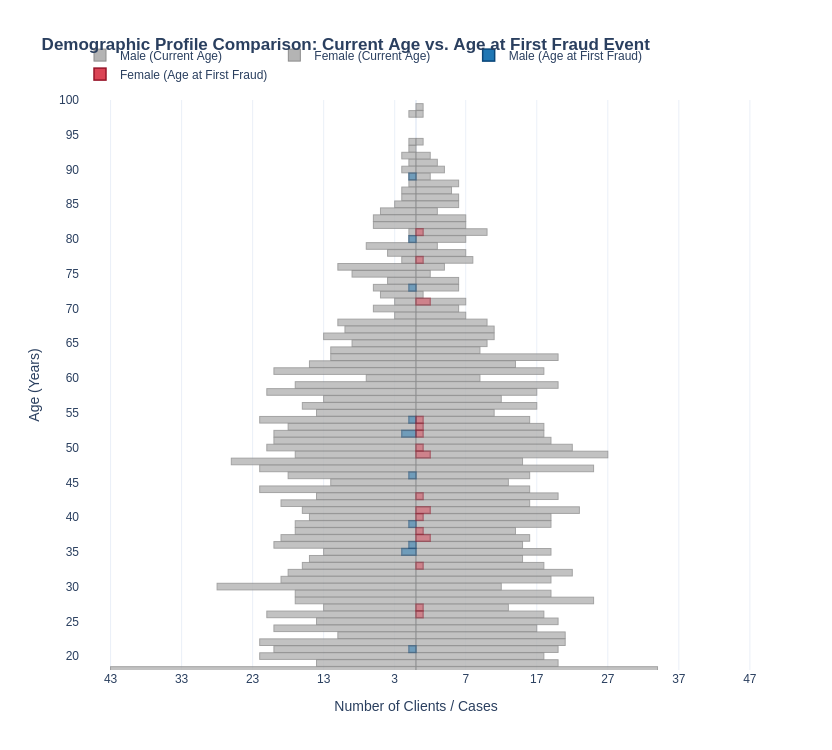

In [57]:
demographic_pd = demographic_df
males_gen = demographic_pd[demographic_pd["gender"] == "Male"]
females_gen = demographic_pd[demographic_pd["gender"] == "Female"]

demographic_first_fraud_age_pd = demographic_first_fraud_age_df
males_frd = demographic_first_fraud_age_pd[demographic_first_fraud_age_pd["gender"] == "Male"]
females_frd = demographic_first_fraud_age_pd[demographic_first_fraud_age_pd["gender"] == "Female"]


demographic_fig = go.Figure()

demographic_fig.add_trace(go.Bar(
    y=males_gen["current_age"],
    x=males_gen["count_pyramid"],
    name="Male (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Males: %{customdata:,}<extra></extra>",
    customdata=males_gen["count"]
))
demographic_fig.add_trace(go.Bar(
    y=females_gen["current_age"],
    x=females_gen["count_pyramid"],
    name="Female (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Females: %{x:,}<extra></extra>"
))

demographic_fig.add_trace(go.Bar(
    y=males_frd["age_at_first_fraud"],
    x=males_frd["count_pyramid"],
    name="Male (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#1F77B4", opacity=0.5, line=dict(color="#0A4678", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Males: %{customdata:,}<extra></extra>",
    customdata=males_frd["count"]
))
demographic_fig.add_trace(go.Bar(
    y=females_frd["age_at_first_fraud"],
    x=females_frd["count_pyramid"],
    name="Female (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#DB4455", opacity=0.5, line=dict(color="#961428", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Females: %{x:,}<extra></extra>"
))

max_count = int(max(demographic_pd["count"].max(), demographic_first_fraud_age_pd["count"].max()))
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fig.update_layout(
    title="<b>Demographic Profile Comparison: Current Age vs. Age at First Fraud Event</b>",
    barmode="overlay",        
    bargap=0.05, height=750, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(
        title="Number of Clients / Cases", 
        tickvals=tick_vals, ticktext=tick_text, range=[-max_count * 1.1, max_count * 1.1]
    ),
    yaxis=dict(title="Age (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white"
)

demographic_fig.show()

In [53]:
males_gen

,current_age,gender,Total,count_pyramid
1,18,Male,43,-43
25,30,Male,28,-28
61,48,Male,26,-26
73,54,Male,22,-22
9,22,Male,22,-22
...,...,...,...,...
141,88,Male,1,-1
147,91,Male,1,-1
150,93,Male,1,-1
152,94,Male,1,-1


In [78]:
demographic_fraud_age_df = (
    fraud_data_df.loc[
        fraud_data_df["target"],
        ["gender", "target", "date", "birth_year"]
        ]
)

demographic_fraud_age_df["age_at_transaction"]=(
    demographic_fraud_age_df["date"].dt.year - demographic_fraud_age_df["birth_year"]
)

demographic_fraud_age_df = (
    demographic_fraud_age_df
        .groupby(["gender", "age_at_transaction"], observed = True)
        .size()
        .reset_index(name="Total")  
)

demographic_fraud_age_df['Total_pyramid'] = np.where(
    demographic_fraud_age_df['gender'] == 'Male',
    demographic_fraud_age_df['Total'] * -1,
    demographic_fraud_age_df['Total']
)

demographic_fraud_age_df.info()
demographic_fraud_age_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   gender              26 non-null     category
 1   age_at_transaction  26 non-null     int64   
 2   Total               26 non-null     int64   
 3   Total_pyramid       26 non-null     int64   
dtypes: category(1), int64(3)
memory usage: 906.0 bytes


,gender,age_at_transaction,Total,Total_pyramid
0,Male,21,6,-6
1,Male,35,9,-9
2,Male,36,1,-1
3,Male,39,5,-5
4,Male,46,1,-1


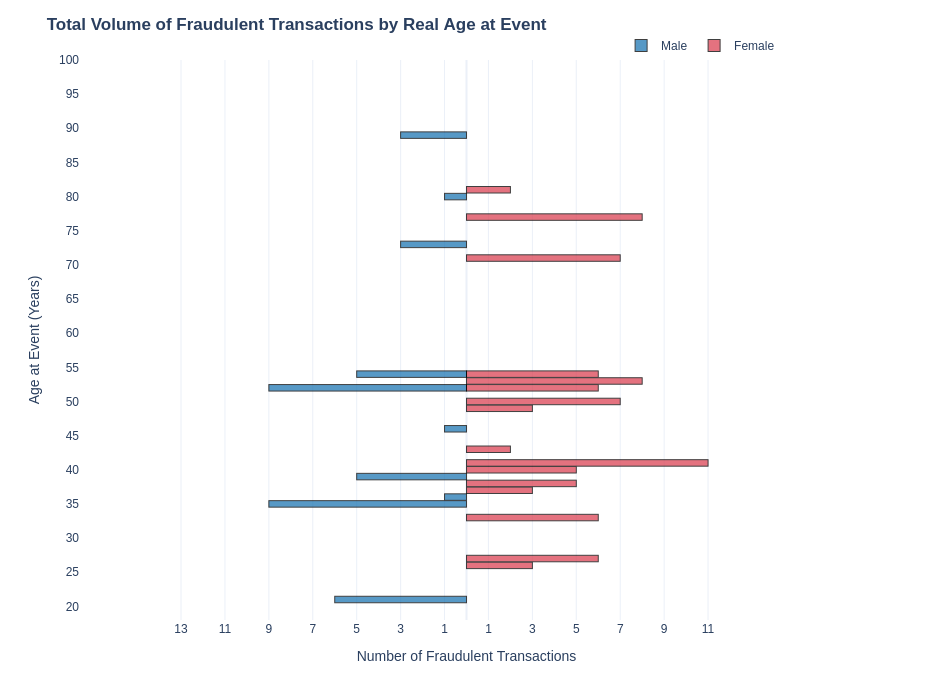

In [69]:
demographic_fraud_age_pd = demographic_fraud_age_df

demographic_fraud_age_fig = px.bar(
    demographic_fraud_age_pd,
    x="Total_pyramid",
    y="age_at_transaction",
    color="gender",  
    orientation="h",
    color_discrete_map={"Male": "#1F77B4", "Female": "#DB4455"},
    custom_data=["Total"]
)

demographic_fraud_age_fig.update_traces(
    opacity=0.75,
    marker_line_width=1., marker_line_color="#000000",
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Transactions: %{customdata[0]:,}<extra></extra>"
)

max_count = int(demographic_fraud_age_pd["Total"].max())
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fraud_age_fig.update_layout(
    title="<b>Total Volume of Fraudulent Transactions by Real Age at Event</b>",
    barmode="overlay", bargap=0.05, 
    height=700, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="left", x=0.7, title=None),
    xaxis=dict(
        title="Number of Fraudulent Transactions",
        tickvals=tick_vals, ticktext=tick_text, 
        range=[-max_count * 1.6, max_count * 1.6]
    ),
    yaxis=dict(title="Age at Event (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white",
)

demographic_fraud_age_fig.show()

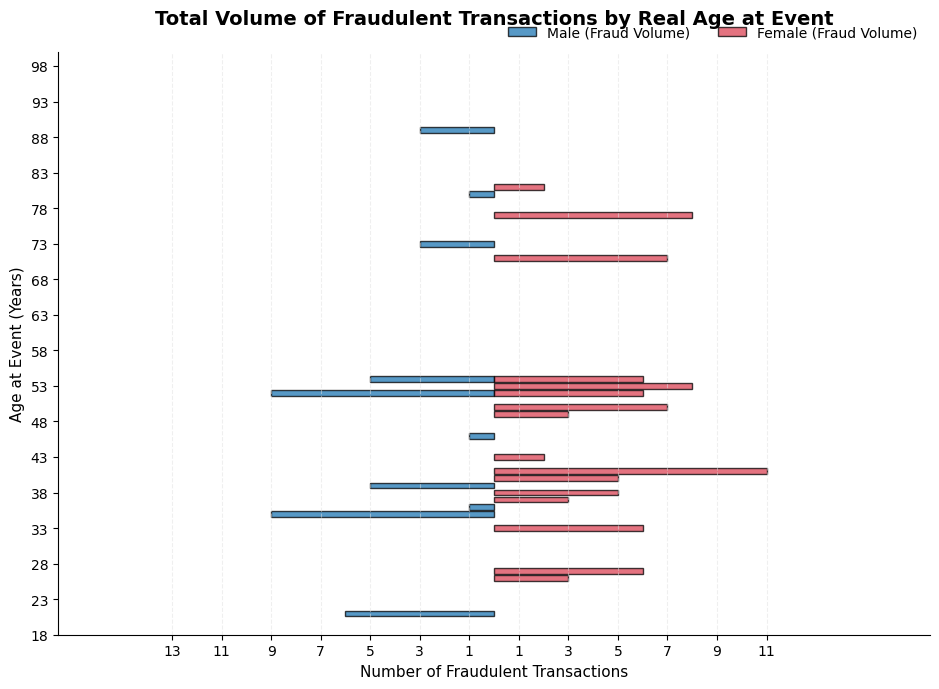

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Separar los datos por género (necesario en Matplotlib)
males = demographic_fraud_age_pd[demographic_fraud_age_pd["gender"] == "Male"]
females = demographic_fraud_age_pd[demographic_fraud_age_pd["gender"] == "Female"]

# 2. Configurar el tamaño de la figura (equivalente a tu height/width de Plotly)
fig, ax = plt.subplots(figsize=(9.5, 7.0))

# 3. Dibujar las barras horizontales con tus colores, bordes negros y opacidad
ax.barh(
    males["age_at_transaction"], males["Total_pyramid"], 
    color="#1F77B4", edgecolor="#000000", linewidth=1.0, alpha=0.75, 
    label="Male (Fraud Volume)"
)
ax.barh(
    females["age_at_transaction"], females["Total_pyramid"], 
    color="#DB4455", edgecolor="#000000", linewidth=1.0, alpha=0.75, 
    label="Female (Fraud Volume)"
)

# --- Tus mismos cálculos matemáticos para el eje X ---
max_count = int(demographic_fraud_age_pd["Total"].max())
tick_step = max(1, max_count // 4)
# Creamos la lista de posiciones de los ticks
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
# Quitamos el signo negativo a los textos del eje X
tick_text = [f"{abs(v):,}" for v in tick_vals]

# 4. Configurar límites y etiquetas de los ejes
ax.set_xlim(-max_count * 1.6, max_count * 1.6)
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_text)

ax.set_ylim(18, 100)
ax.set_yticks(range(18, 101, 5)) # dtick=5 de Plotly

# 5. Títulos y etiquetas de texto
ax.set_title("Total Volume of Fraudulent Transactions by Real Age at Event", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Number of Fraudulent Transactions", fontsize=11)
ax.set_ylabel("Age at Event (Years)", fontsize=11)

# 6. Configurar la Leyenda (Horizontal en la parte superior derecha)
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2, frameon=False)

# 7. Estilo de fondo limpio (equivalente a plotly_white)
ax.set_facecolor("white")
ax.grid(True, axis="x", linestyle="--", alpha=0.5, color="#E0E0E0") # Líneas de guía verticales ocultando las de Y
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


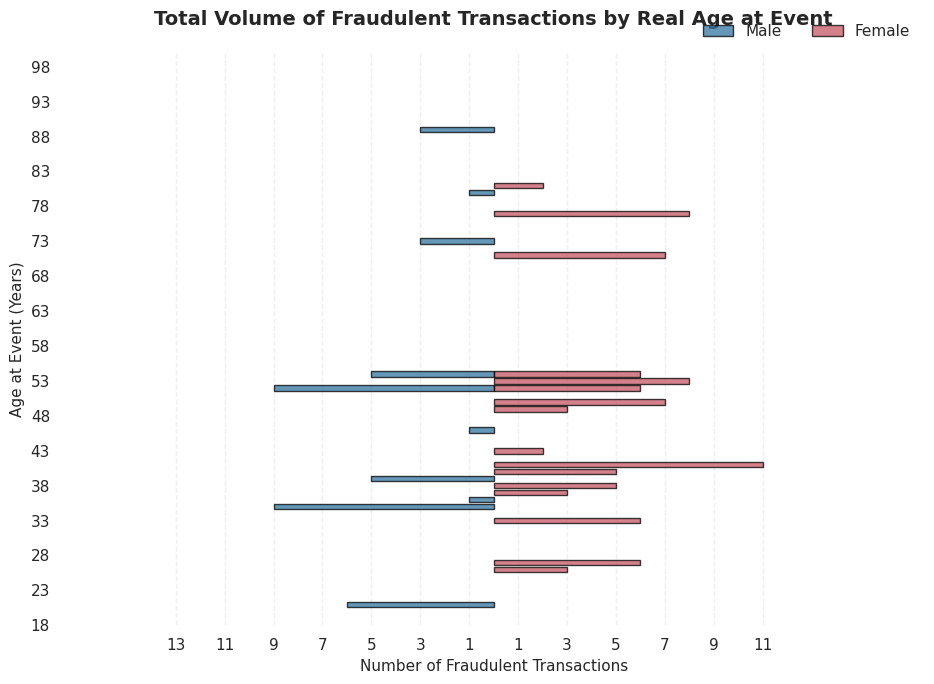

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo básico y tamaño de la figura (Estilo limpio blanco)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9.5, 7.0))

# 2. Crear el gráfico con Seaborn
# Usamos 'hue' para separar por género y 'palette' para mantener tus colores exactos
sns.barplot(
    data=demographic_fraud_age_pd,
    x="Total_pyramid",
    y="age_at_transaction",
    hue="gender",
    orient="h",  # Gráfico horizontal
    palette={"Male": "#1F77B4", "Female": "#DB4455"},
    alpha=0.75,
    edgecolor="#000000",
    linewidth=1.0,
    native_scale=True,
    ax=ax,
    dodge=False  # Superpone las barras en el eje Y en lugar de moverlas de carril
)

# --- Tus mismos cálculos matemáticos para el eje X (Sin signos negativos) ---
max_count = int(demographic_fraud_age_pd["Total"].max())
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [f"{abs(v):,}" for v in tick_vals]

# 3. Personalizar ejes y límites (Lógica de Matplotlib que acompaña a Seaborn)
ax.set_xlim(-max_count * 1.6, max_count * 1.6)
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_text)

# Limitar el rango de edad de 18 a 100 años con saltos de 5 en 5
ax.set_ylim(18, 100)
# Como Seaborn puede tratar la edad de forma categórica si hay huecos,
# forzamos los cortes numéricos exactos en el eje Y:
ax.set_yticks(range(18, 101, 5))

# 4. Títulos y etiquetas personalizados
ax.set_title("Total Volume of Fraudulent Transactions by Real Age at Event", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Number of Fraudulent Transactions", fontsize=11)
ax.set_ylabel("Age at Event (Years)", fontsize=11)

# 5. Mover la leyenda a la parte superior derecha de forma horizontal
sns.move_legend(
    ax, "lower right",
    bbox_to_anchor=(1.0, 1.0), ncol=2, title=None, frameon=False
)

# 6. Añadir líneas de guía de fondo (Grid)
ax.grid(True, axis="x", linestyle="--", alpha=0.5, color="#E0E0E0")
sns.despine(left=True, bottom=True) # Elimina los bordes del recuadro del gráfico

plt.tight_layout()
plt.show()
